# CO543: Image Processing - Lab 3

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show(img, title="Image"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')

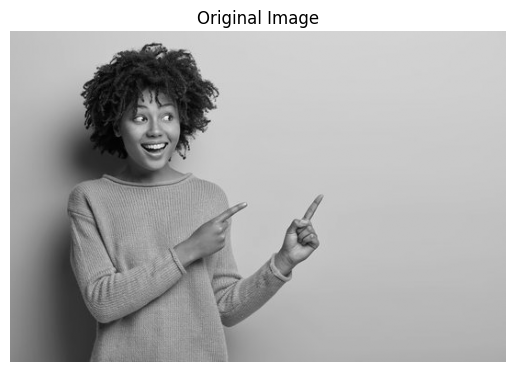

In [5]:
img = cv2.imread('face.jpg', cv2.IMREAD_GRAYSCALE)
show(img, "Original Image")

#Task 1 — Simulate Salt-and-Pepper Noise

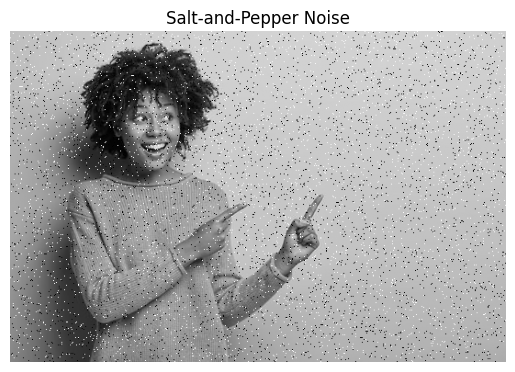

In [6]:
noisy = img.copy()
prob = 0.02

rand = np.random.rand(*img.shape)
noisy[rand < prob] = 255        # salt
noisy[rand > 1 - prob] = 0      # pepper

show(noisy, "Salt-and-Pepper Noise")

**How noise disrupts fine facial structure and why randomness breaks
visual continuity**

Fine facial structures such as eyes, eyelashes, skin texture, lips, and wrinkles rely on small, smooth intensity variations. Noise randomly alters pixel values, which:

* Breaks smooth shading on skin

* Distorts thin features like eyebrows and eyelashes

* Introduces false bright or dark spots that look like texture but are not real

* Masks subtle details that define facial expressions

As a result, important facial features lose clarity and realism.



Visual continuity exists when neighboring pixels change gradually and meaningfully, forming edges, contours, and textures. Random noise breaks this because:

* Noise pixels appear independent of their neighbors

* There is no consistent pattern or direction

* Abrupt intensity changes occur where none should exist

This causes edges to appear jagged, surfaces to look rough, and structures to lose coherence, making the image harder for both humans and algorithms to interpret.

**Why is random noise more damaging than uniform blur?**

Random noise is more damaging than uniform blur because it disrupts image structure unpredictably, whereas uniform blur degrades details consistently while preserving overall shapes and continuity.

# Task 2 — Apply Mean Filter

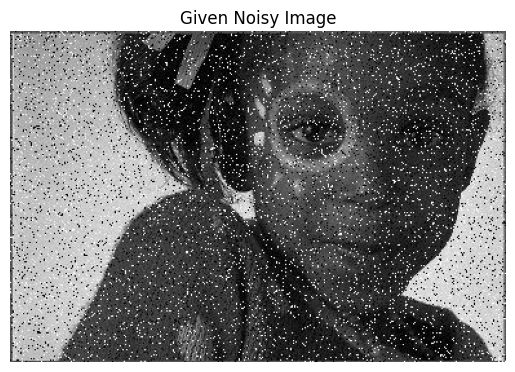

In [12]:
noisy2 = cv2.imread('Sample image.jpg', cv2.IMREAD_GRAYSCALE)
show(noisy2, "Given Noisy Image")

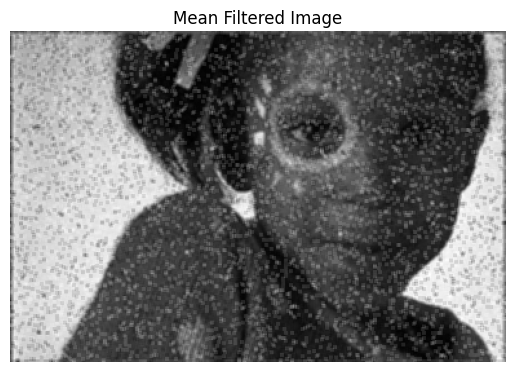

In [15]:
mean = cv2.blur(noisy2, (3,3))
show(mean, "Mean Filtered Image")

**Why does the image become blurry?**

A mean filter replaces each pixel with the average of its neighbors.
This averaging:
* Reduces small noise variations
* Also reduces intensity differences at edges

Edges depend on sharp intensity changes
Averaging smooths these changes -- blur


**Why does naive smoothing destroy edge sharpness?**
At an edge:
* One side is dark
* Other side is bright

Mean filtering mixes both sides, so:
* Dark pixels become brighter
* Bright pixels become darker
* The edge becomes washed out

**Why is blurring sometimes acceptable in low-detail backgrounds?**

Blurring is acceptable in low-detail backgrounds because these regions contain minimal structural information, so smoothing reduces noise without noticeably degrading important visual features.

# Task 3 — Median Filter for Salt-Pepper

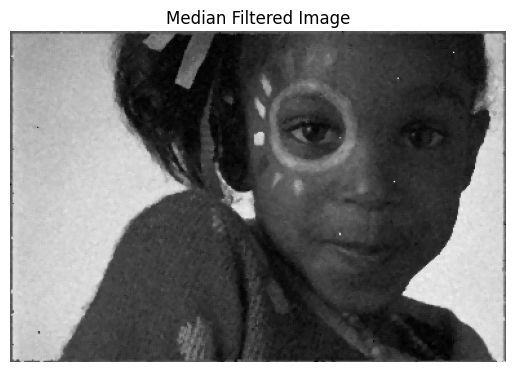

In [13]:
median2 = cv2.medianBlur(noisy2, 3)
show(median2, "Median Filtered Image")

**How median preserves edges and eliminates impulses more effectively?**

The median filter replaces each pixel with the median value of its neighborhood. This effectively removes salt-and-pepper noise because extreme pixel values are discarded. Unlike mean filtering, median filtering preserves edge sharpness since edges are not averaged across.

**Why does median treat noise differently from mean?**

Median filtering removes noise by selecting the middle value rather than averaging all values. This prevents extreme noise values from influencing the result, making it especially effective for impulse noise.

# Task 4 — Gaussian Smoothing

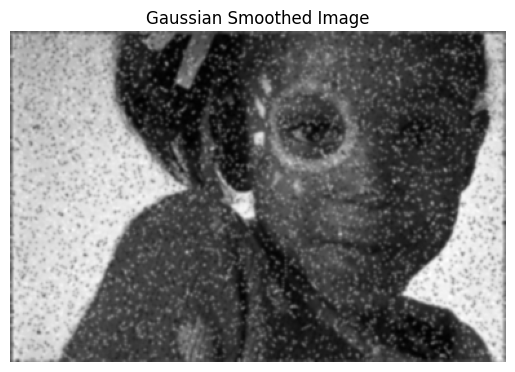

In [16]:
gauss2 = cv2.GaussianBlur(noisy2, (5,5), 1)
show(gauss2, "Gaussian Smoothed Image")

**Introduce Gaussian blur and examine trade-offs between noise reduction and structural loss.**

Gaussian smoothing reduces noise by averaging pixels with weights determined by a Gaussian function. Nearby pixels contribute more than distant ones, producing a smoother and more natural-looking image. However, increasing the smoothing strength can lead to loss of fine details.

**Why does Gaussian blur feel visually “natural”?**

Gaussian blur resembles the way light spreads in optical systems and human vision, making the smoothing effect appear more natural and less artificial.

# Task 5 — Bilateral Filtering for Edge Preservation

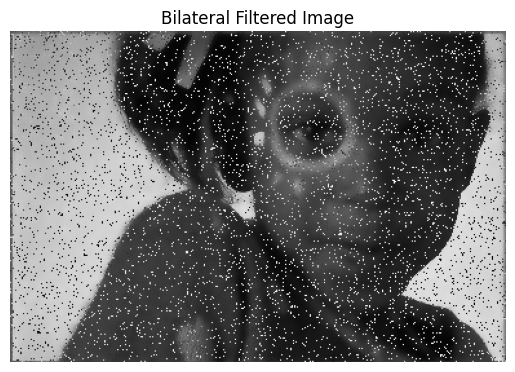

In [17]:
bil2 = cv2.bilateralFilter(noisy2, 9, 60, 60)
show(bil2, "Bilateral Filtered Image")

**Explain how preserving edge discontinuities keeps facial identity intact.**

Bilateral filtering reduces noise while preserving edges by considering both spatial distance and intensity difference between pixels. Pixels with similar intensities are averaged, while pixels across edges are not mixed, helping retain important facial structures.

**Why are edge-aware filters more computationally expensive?**


Edge-aware filters require additional computations to compare both pixel distance and intensity differences, making them slower than simple averaging filters.

# Task 6 — Laplacian Sharpening

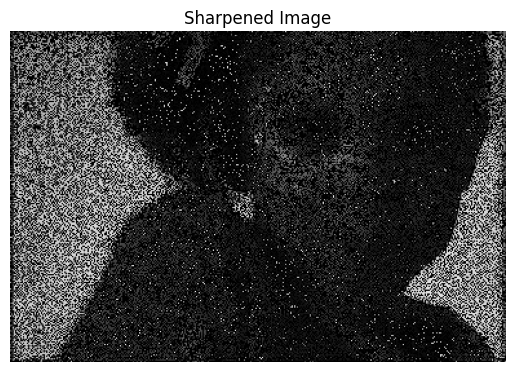

In [18]:
lap2 = cv2.Laplacian(bil2, cv2.CV_64F)
sharp2 = cv2.subtract(bil2, lap2.astype(np.uint8))
show(sharp2, "Sharpened Image")

**Comment on how sharpening emphasizes structural boundaries
but can re-magnify noise if misused.**

Laplacian sharpening enhances edges by emphasizing regions of rapid intensity change. While it improves structural boundaries, excessive sharpening can amplify residual noise and produce unnatural artifacts.

**Can sharpening fully recover high-frequency details lost during filtering ?**

Sharpening cannot fully recover lost details because information removed during smoothing is permanently discarded. It can only enhance remaining edges, not restore original high-frequency content.

# Final Reflection

**Write one paragraph describing the balance between denoising and detail retention. Which filter produced the best compromise and why?**

Noise removal requires a balance between smoothing and detail preservation. Mean and Gaussian filters reduce noise but blur edges, while median filtering effectively removes impulse noise. Bilateral filtering provides the best compromise by reducing noise while preserving important edges. Sharpening improves visual clarity but must be applied carefully to avoid re-amplifying noise.